# Experiment 1 — The Vanilla Baseline (Equal-Strength Covariates)

**Goal:** Establish the baseline failure point for the LOO benchmark under the most symmetric,
best-case setup — all observed covariates are equally informative.

**Setup**
- $D^* = X\beta_{DX} + A\beta_{DA} + \varepsilon_D$, $\quad D = \mathbf{1}[D^* > 0]$
- $Y = \tau D + X\beta_{YX} + A\beta_{YA} + \varepsilon_Y$
- $\tau_{\text{true}} = 1.0$
- $\beta_{DX} = \beta_{YX} = [0.5, 0.5, 0.5, 0.5, 0.5]$ — all covariates equal strength.
  This is the symmetric control: every $X_j$ contributes identically, so $B_{\max}$ is
  determined by any single leave-one-out covariate.
- Multiplier $m$ sweeps from $0.5$ to $2.0$ (50 steps):
  $\beta_{DA} = \beta_{YA} = 0.5m$

**Benchmark:** LOO (leave-one-out) — for each observed $X_j$, treat it as the mock omitted
confounder and compute bound $B_j$.

$B_{\max} = \max_j B_j$.

**Coverage metric:** across 250 Monte Carlo trials per multiplier,
$$\text{Coverage}(m) = \Pr\bigl(|\hat{\tau}_{\text{short}} - \tau_{\text{true}}| \le B_{\max}\bigr)$$

This is the **control experiment**. Compare its cliff location to Experiment 2 (superstar
covariate) to quantify how much a single dominant predictor extends the safe zone.

In [12]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from dgp import DGPConfig, generate_data
from loo_benchmark import loo_benchmark
from ovb_formula import compute_RV
from robustness_plot import plot_robustness_contour

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [2]:
tau_true   = 1.0
n_trials   = 100

# Uniform beta — every X_j has identical strength; exchangeable by construction
beta_dx    = 0.5
beta_yx    = 0.5

multipliers = np.linspace(0.5, 2.5, 50)

coverage        = []
mean_ovb        = []
mean_Bmax       = []
mean_RV         = []
mean_rho        = []     # absolute tightness: |OVB| / B_max
mean_signed_rho = []     # signed tightness: (τ_short − τ_true) / B_max (preserves direction)
p10_rho         = []
p90_rho         = []
p10_signed_rho  = []
p90_signed_rho  = []
mean_sig_slack  = []     # (lower 95% CI) / B_max — practitioner headroom, NOT a validity diagnostic
mean_r2_ax      = []     # R²(A ~ X) — god-mode proxy quality
last_trial_data = {}

for m_idx, multiplier in enumerate(multipliers):
    beta_da = 0.5 * multiplier
    beta_ya = 0.5 * multiplier   # same-direction: positive confounding

    covered         = 0
    ovb_vals        = []
    B_vals          = []
    rv_vals         = []
    rho_vals        = []
    signed_rho_vals = []
    sig_slack_vals  = []
    r2_ax_vals      = []

    for trial in range(n_trials):
        seed = m_idx * n_trials + trial

        config = DGPConfig(
            num_X=5, num_A=1,
            beta_dx=beta_dx, beta_da=beta_da,
            beta_yx=beta_yx, beta_ya=beta_ya,
            seed=seed,
        )
        Y, D, X, A = generate_data(config)

        short_fit = sm.OLS(Y, sm.add_constant(np.column_stack([D, X]))).fit()
        tau_short = short_fit.params[1]
        se_short  = short_fit.bse[1]

        loo_results, S2_full = loo_benchmark(Y, D, X)
        B_max = max(r['B'] for r in loo_results)
        RV    = compute_RV(tau_short, S2_full)

        ovb = abs(tau_short - tau_true)
        ovb_vals.append(ovb)
        B_vals.append(B_max)
        rv_vals.append(RV)

        # Absolute tightness: fraction of LOO budget consumed by actual bias
        rho_vals.append(ovb / B_max if B_max > 0 else np.nan)

        # Signed tightness: positive → upward bias; preserves direction for asymmetry analysis
        signed_ovb = tau_short - tau_true
        signed_rho_vals.append(signed_ovb / B_max if B_max > 0 else np.nan)

        # Significance slack: lower 95% CI relative to the LOO budget.
        # Practitioner-facing only — measures headroom before significance is lost, not bound validity.
        lower_ci = abs(tau_short) - 1.96 * se_short
        sig_slack_vals.append(lower_ci / B_max if B_max > 0 else np.nan)

        # God-mode: how much of A's variance does X capture?
        r2_ax_vals.append(sm.OLS(A[:, 0], sm.add_constant(X)).fit().rsquared)

        if ovb <= B_max:
            covered += 1

        last_trial_data[m_idx] = (tau_short, S2_full, loo_results)

    coverage.append(100.0 * covered / n_trials)
    mean_ovb.append(np.mean(ovb_vals))
    mean_Bmax.append(np.mean(B_vals))
    mean_RV.append(np.mean(rv_vals))
    mean_rho.append(np.nanmean(rho_vals))
    mean_signed_rho.append(np.nanmean(signed_rho_vals))
    p10_rho.append(np.nanpercentile(rho_vals, 10))
    p90_rho.append(np.nanpercentile(rho_vals, 90))
    p10_signed_rho.append(np.nanpercentile(signed_rho_vals, 10))
    p90_signed_rho.append(np.nanpercentile(signed_rho_vals, 90))
    mean_sig_slack.append(np.nanmean(sig_slack_vals))
    mean_r2_ax.append(np.nanmean(r2_ax_vals))

    print(f"m={multiplier:5.2f}  coverage={coverage[-1]:5.1f}%  "
          f"mean|OVB|={mean_ovb[-1]:.4f}  mean B_max={mean_Bmax[-1]:.4f}  "
          f"mean RV={mean_RV[-1]:.4f}  mean ρ={mean_rho[-1]:.3f}  "
          f"signed ρ={mean_signed_rho[-1]:.3f}  "
          f"sig_slack={mean_sig_slack[-1]:.3f}  R²(A|X)={mean_r2_ax[-1]:.4f}")

m= 0.50  coverage=100.0%  mean|OVB|=0.1027  mean B_max=0.3700  mean RV=0.4330  mean ρ=0.280  signed ρ=0.272  sig_slack=2.682  R²(A|X)=0.0023
m= 0.54  coverage=100.0%  mean|OVB|=0.1156  mean B_max=0.3654  mean RV=0.4379  mean ρ=0.319  signed ρ=0.313  sig_slack=2.753  R²(A|X)=0.0025
m= 0.58  coverage=100.0%  mean|OVB|=0.1358  mean B_max=0.3648  mean RV=0.4427  mean ρ=0.376  signed ρ=0.376  sig_slack=2.818  R²(A|X)=0.0025
m= 0.62  coverage=100.0%  mean|OVB|=0.1484  mean B_max=0.3625  mean RV=0.4455  mean ρ=0.413  signed ρ=0.410  sig_slack=2.866  R²(A|X)=0.0027
m= 0.66  coverage= 99.0%  mean|OVB|=0.1634  mean B_max=0.3532  mean RV=0.4516  mean ρ=0.465  signed ρ=0.465  sig_slack=2.981  R²(A|X)=0.0025
m= 0.70  coverage= 98.0%  mean|OVB|=0.2020  mean B_max=0.3565  mean RV=0.4631  mean ρ=0.568  signed ρ=0.568  sig_slack=3.062  R²(A|X)=0.0024
m= 0.74  coverage= 98.0%  mean|OVB|=0.2274  mean B_max=0.3508  mean RV=0.4698  mean ρ=0.652  signed ρ=0.652  sig_slack=3.185  R²(A|X)=0.0028
m= 0.79  cove

In [3]:
np.save('results/experiment_01_results.npy', {
    'multipliers':      np.array(multipliers),
    'coverage':         np.array(coverage),
    'mean_ovb':         np.array(mean_ovb),
    'mean_Bmax':        np.array(mean_Bmax),
    'mean_RV':          np.array(mean_RV),
    'mean_rho':         np.array(mean_rho),
    'mean_signed_rho':  np.array(mean_signed_rho),
    'p10_rho':          np.array(p10_rho),
    'p90_rho':          np.array(p90_rho),
    'p10_signed_rho':   np.array(p10_signed_rho),
    'p90_signed_rho':   np.array(p90_signed_rho),
    'mean_sig_slack':   np.array(mean_sig_slack),
    'mean_r2_ax':       np.array(mean_r2_ax),
}, allow_pickle=True)
print("Saved → results/experiment_01_results.npy")

Saved → results/experiment_01_results.npy


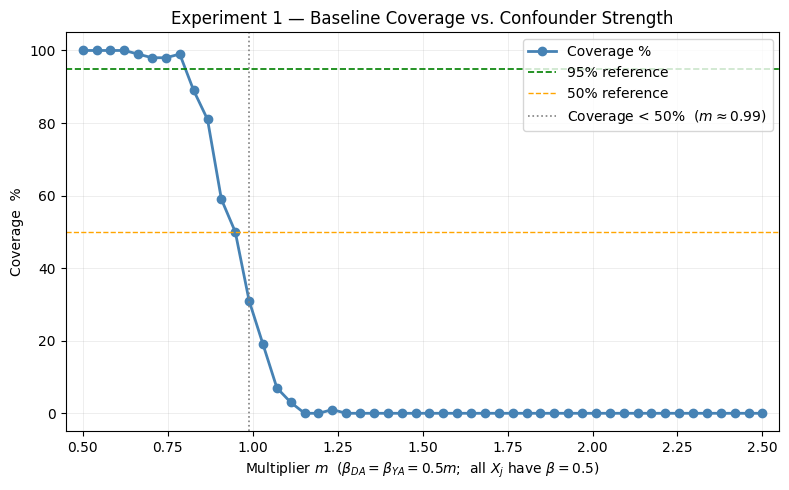

In [4]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, coverage, marker='o', linewidth=2, color='steelblue', label='Coverage %')
ax.axhline(95, linestyle='--', color='green',  linewidth=1.2, label='95% reference')
ax.axhline(50, linestyle='--', color='orange', linewidth=1.0, label='50% reference')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=\beta_{YA}=0.5m$;  all $X_j$ have $\beta=0.5$)')
ax.set_ylabel('Coverage  %')
ax.set_title('Experiment 1 — Baseline Coverage vs. Confounder Strength')
ax.set_ylim(-5, 105)
ax.set_xlim(multipliers[0] - 0.05, multipliers[-1] + 0.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_coverage.png', bbox_inches='tight')
plt.show()

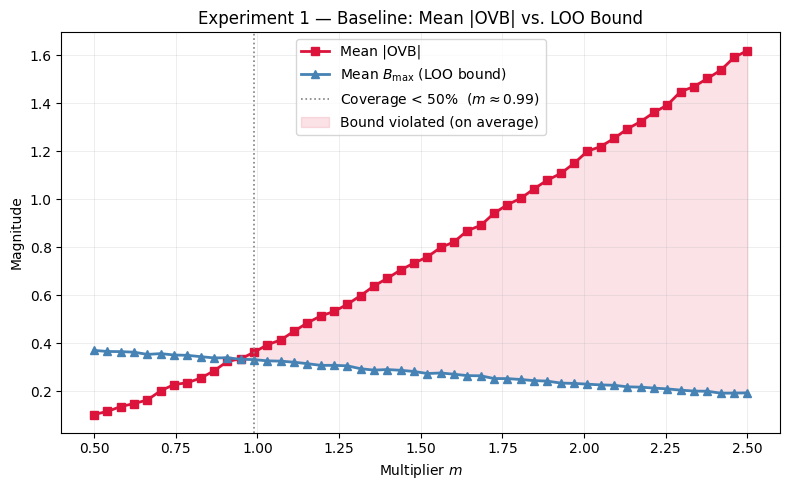

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_ovb,  marker='s', linewidth=2, color='crimson',
        label='Mean |OVB|')
ax.plot(multipliers, mean_Bmax, marker='^', linewidth=2, color='steelblue',
        label=r'Mean $B_{\max}$ (LOO bound)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ovb_arr  = np.array(mean_ovb)
bmax_arr = np.array(mean_Bmax)
ax.fill_between(multipliers, ovb_arr, bmax_arr,
                where=(ovb_arr > bmax_arr),
                color='crimson', alpha=0.12, label='Bound violated (on average)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel('Magnitude')
ax.set_title('Experiment 1 — Baseline: Mean |OVB| vs. LOO Bound')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_ovb_vs_bound.png', bbox_inches='tight')
plt.show()

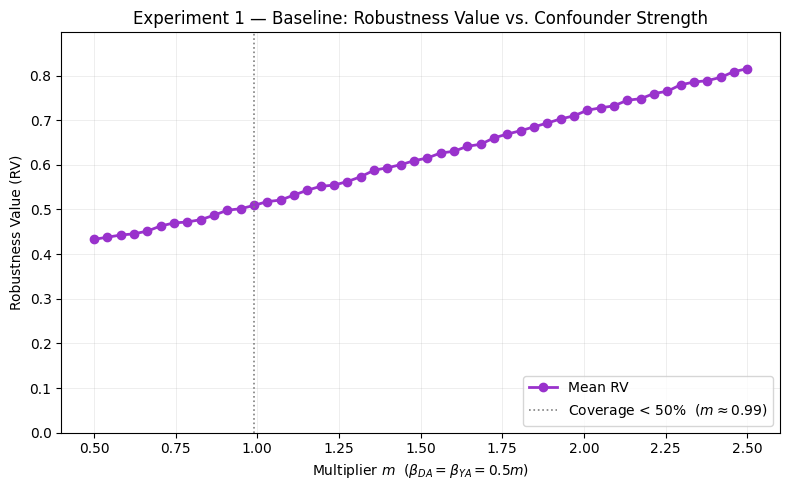

In [6]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_RV, marker='o', linewidth=2, color='darkorchid', label='Mean RV')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=\beta_{YA}=0.5m$)')
ax.set_ylabel('Robustness Value (RV)')
ax.set_title('Experiment 1 — Baseline: Robustness Value vs. Confounder Strength')
ax.set_ylim(0, max(mean_RV) * 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_rv.png', bbox_inches='tight')
plt.show()

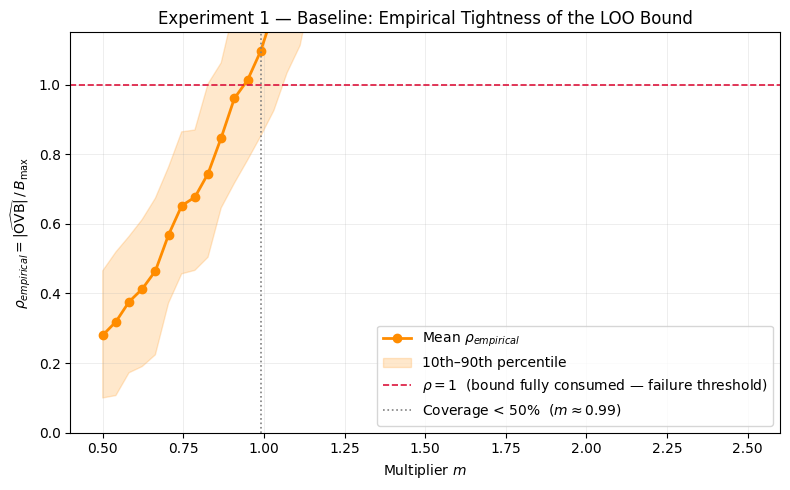

In [7]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_rho, marker='o', linewidth=2, color='darkorange',
        label=r'Mean $\rho_{empirical}$')
ax.fill_between(multipliers, p10_rho, p90_rho,
                alpha=0.2, color='darkorange', label='10th–90th percentile')
ax.axhline(1.0, linestyle='--', color='crimson', linewidth=1.2,
           label=r'$\rho = 1$  (bound fully consumed — failure threshold)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(r'$\rho_{empirical} = |\widehat{\mathrm{OVB}}| \,/\, B_{\max}$')
ax.set_title('Experiment 1 — Baseline: Empirical Tightness of the LOO Bound')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_rho.png', bbox_inches='tight')
plt.show()

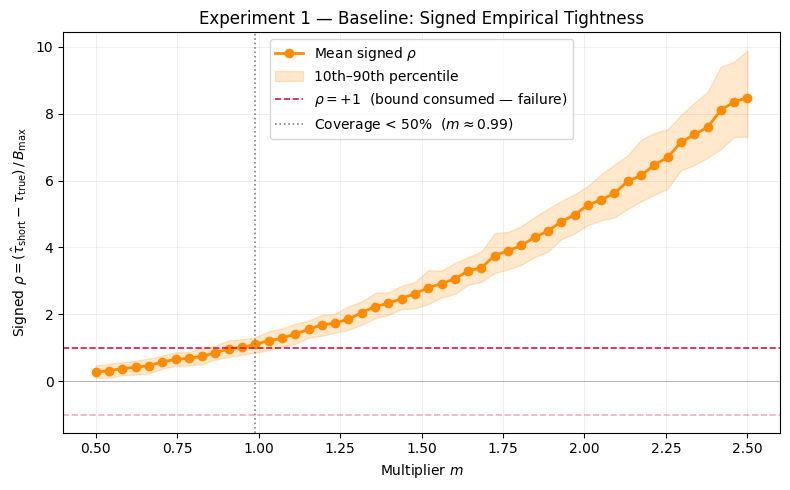

In [8]:
# Signed empirical tightness — preserves direction of bias.
# For same-direction (positive) confounding, signed ρ > 0 throughout, and
# crosses +1 at the cliff.  The mirror experiment (Exp 3, β_ya < 0) would
# produce a reflection crossing −1, enabling the four-panel direction comparison.
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_signed_rho, marker='o', linewidth=2, color='darkorange',
        label=r'Mean signed $\rho$')
ax.fill_between(multipliers, p10_signed_rho, p90_signed_rho,
                alpha=0.2, color='darkorange', label='10th–90th percentile')
ax.axhline( 1.0, linestyle='--', color='crimson', linewidth=1.2,
            label=r'$\rho = +1$  (bound consumed — failure)')
ax.axhline(-1.0, linestyle='--', color='crimson', linewidth=1.2, alpha=0.35)
ax.axhline( 0.0, linestyle='-',  color='gray',    linewidth=0.8, alpha=0.5)
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(
    r'Signed $\rho = (\hat{\tau}_{\mathrm{short}} - \tau_{\mathrm{true}}) \,/\, B_{\max}$'
)
ax.set_title('Experiment 1 — Baseline: Signed Empirical Tightness')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_signed_rho.png', bbox_inches='tight')
plt.show()

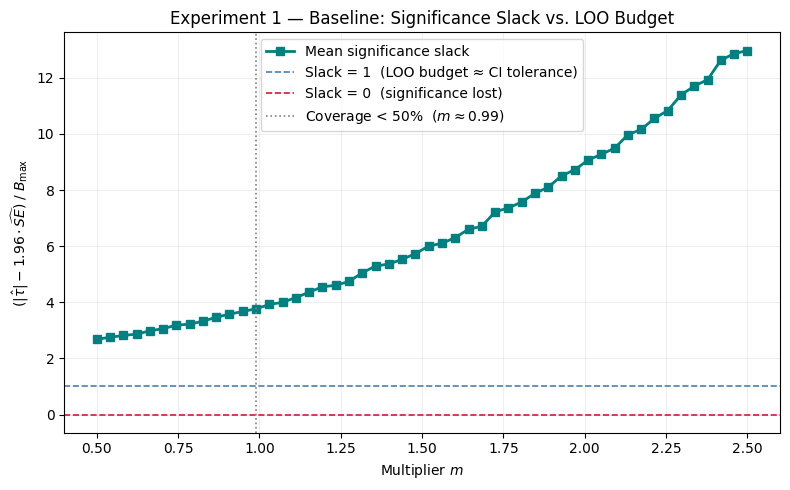

In [9]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_sig_slack, marker='s', linewidth=2, color='teal',
        label='Mean significance slack')
ax.axhline(1.0, linestyle='--', color='steelblue', linewidth=1.2,
           label='Slack = 1  (LOO budget ≈ CI tolerance)')
ax.axhline(0.0, linestyle='--', color='crimson', linewidth=1.2,
           label='Slack = 0  (significance lost)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel(r'$(|\hat{\tau}| - 1.96 \cdot \widehat{SE}) \;/\; B_{\max}$')
ax.set_title('Experiment 1 — Baseline: Significance Slack vs. LOO Budget')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_sig_slack.png', bbox_inches='tight')
plt.show()

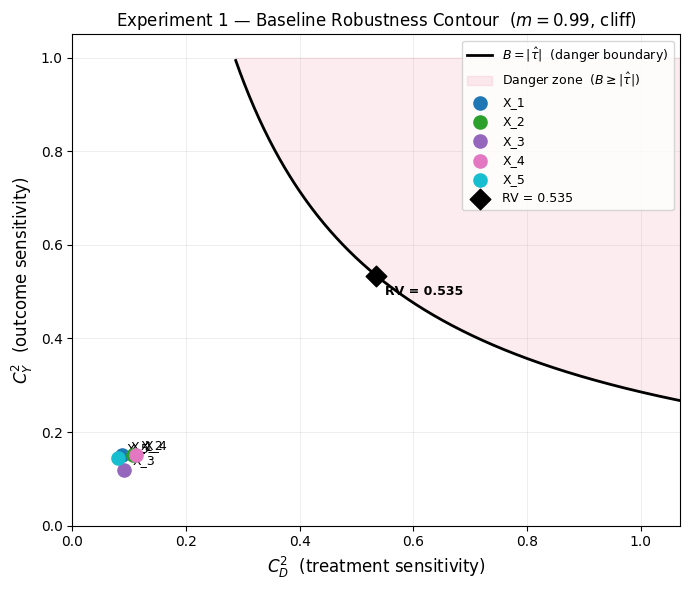

In [10]:
# Robustness contour at the cliff multiplier (first m where coverage < 50%)
cliff_idx  = next((i for i, c in enumerate(coverage) if c < 50), len(multipliers) - 1)
cliff_m    = multipliers[cliff_idx]
tau_s, S2, loo_r = last_trial_data[cliff_idx]

fig, ax = plt.subplots(figsize=(7, 6))
plot_robustness_contour(
    tau_hat     = tau_s,
    S2          = S2,
    loo_results = loo_r,
    ax          = ax,
    title       = f'Experiment 1 — Baseline Robustness Contour  ($m = {cliff_m:.2f}$, cliff)',
)
plt.tight_layout()
plt.savefig('figures/experiment_01_baseline_contour.png', bbox_inches='tight')
plt.show()

In [11]:
import pandas as pd
from IPython.display import display

# ── Validity diagnostics ─────────────────────────────────────────────────────
# The three columns that directly answer "does the LOO bound do its job?"
# sig_slack is deliberately absent: it answers a different question (what the
# practitioner sees) and belongs in the practitioner panel below.
df_valid = pd.DataFrame({
    'Multiplier':   multipliers,
    'Coverage (%)': coverage,
    'Bound Slack':  np.array(mean_Bmax) - np.array(mean_ovb),
    'Mean ρ':       mean_rho,
    'p10 ρ':        p10_rho,
    'p90 ρ':        p90_rho,
    'R²(A|X)':      mean_r2_ax,
}).round(4)

print("Validity Diagnostics  (does the LOO bound cover the true OVB?)")
display(
    df_valid.style.format(precision=4)
    .background_gradient(subset=['Coverage (%)'], cmap='RdYlGn', vmin=0, vmax=100)
    .background_gradient(subset=['Bound Slack'],  cmap='RdYlGn', vmin=-1, vmax=1)
    .background_gradient(subset=['Mean ρ'],       cmap='RdYlGn_r', vmin=0, vmax=2)
)

print()

# ── Practitioner view ────────────────────────────────────────────────────────
# What an analyst sees without god-mode knowledge of A.
# sig_slack > 0 means the LOO budget hasn't consumed the CI yet.
# In same-direction confounding, sig_slack stays large while ρ > 1 — the
# practitioner remains confident while the bound has already been violated.
df_prac = pd.DataFrame({
    'Multiplier':   multipliers,
    'Mean |OVB|':   mean_ovb,
    'Mean B_max':   mean_Bmax,
    'Sig Slack':    mean_sig_slack,
}).round(4)

print("Practitioner View  (what the analyst sees — no knowledge of A)")
display(
    df_prac.style.format(precision=4)
    .background_gradient(subset=['Sig Slack'], cmap='RdYlGn', vmin=-1, vmax=3)
)

Validity Diagnostics  (does the LOO bound cover the true OVB?)


,Multiplier,Coverage (%),Bound Slack,Mean ρ,p10 ρ,p90 ρ,R²(A|X)
0,0.5000,100.0000,0.2672,0.2802,0.0998,0.4649,0.0023
1,0.5408,100.0000,0.2498,0.3188,0.1067,0.5190,0.0025
2,0.5816,100.0000,0.2290,0.3762,0.1722,0.5639,0.0025
3,0.6224,100.0000,0.2141,0.4129,0.1900,0.6124,0.0027
4,0.6633,99.0000,0.1899,0.4647,0.2238,0.6735,0.0025
5,0.7041,98.0000,0.1545,0.5685,0.3722,0.7628,0.0024
6,0.7449,98.0000,0.1233,0.6521,0.4563,0.8642,0.0028
7,0.7857,99.0000,0.1142,0.6766,0.4663,0.8694,0.0024
8,0.8265,89.0000,0.0892,0.7443,0.5040,1.0020,0.0026
9,0.8673,81.0000,0.0537,0.8473,0.6456,1.0625,0.0024



Practitioner View  (what the analyst sees — no knowledge of A)


,Multiplier,Mean |OVB|,Mean B_max,Sig Slack
0,0.5000,0.1027,0.3700,2.6816
1,0.5408,0.1156,0.3654,2.7534
2,0.5816,0.1358,0.3648,2.8183
3,0.6224,0.1484,0.3625,2.8659
4,0.6633,0.1634,0.3532,2.9810
5,0.7041,0.2020,0.3565,3.0616
6,0.7449,0.2274,0.3508,3.1852
7,0.7857,0.2353,0.3494,3.2202
8,0.8265,0.2545,0.3438,3.3263
9,0.8673,0.2849,0.3386,3.4684


## Interpretation

### Why all five X_j dots cluster in the contour plot

The five observed covariates have **identical population parameters** by construction
($\beta_{DX} = \beta_{YX} = 0.5$ for all $j$, independent, unit variance).  They are not
a diverse panel of controls — they are _exchangeable_: every $X_j$ carries the same partial
$R^2$ in both the treatment and outcome models, so the five LOO benchmark values are near-iid
draws from the same distribution.  The scatter in the contour plot is finite-sample noise;
with $n \to \infty$ all five dots converge to a single point.

The "max" in $B_{\max}$ does very little work here: it selects the highest of five near-iid
samples rather than the strongest member of a heterogeneous set.

### What the contour plot does and does not show

The robustness contour answers: *could a confounder of plausible strength **wipe out** the
estimate?*  At the cliff multiplier ($m \approx 0.96$), a confounder with the same partial
$R^2$ as any observed $X_j$ would sit deep in the **safe zone** — far from the danger
boundary.  The contour's verdict at this point is "the estimate is not being explained away,"
which is **technically correct**.

The LOO bound answers: *does $B_{\max}$ cover the actual OVB?*  At the same cliff, this
answer is already "no" — the bound has been violated.  The contour plot is not asking that
question, so the cliff is invisible in it.

These two tools fail in different ways.  The contour understates risk in a world where the
analyst cares about the **value** of $\tau$, not just its sign.  The LOO bound gives a
hard coverage guarantee that collapses sharply at the cliff.

### Safe zone: $m < $ cliff

Coverage holds because $A$'s partial $R^2$ values are smaller than any single $X_j$'s.  All
five LOO benchmarks are essentially identical, so the cliff is **sharp** — there is no
superstar covariate to act as an anchor past the cliff.  Compare to Experiment 2.

### Validity vs. practitioner diagnostics

The summary table above splits these deliberately:
- **Validity diagnostics** (coverage, $\rho$ band, $R^2(A|X)$): answer whether the LOO
  bound covers the true OVB.  $\rho > 1$ means the bound has been violated.
- **Practitioner view** (sig_slack): answers whether the estimate would survive a
  significance test under a worst-case LOO confounder.  In this experiment (positive
  confounding), sig_slack rises monotonically even after $\rho > 1$ — the practitioner
  remains confident while the bound is already broken.  This misleading reassurance is the
  **opposite** of what happens in Experiment 3 (mirror).

### Signed $\rho$ and the direction asymmetry

Because confounding is same-direction here, signed $\rho = $ absolute $\rho$ (always
positive).  The signed form becomes informative only when compared across confounding
directions — see **Experiment 3** for the four-panel figure that exposes how sig_slack
sends opposite signals for the same bound-violation event depending on bias direction.